# 🎮 Lab 1: 강화학습(RL) 원리 이해 — Q-Learning (30분)

## 학습 목표
1. 강화학습의 핵심 개념(상태, 행동, 보상, 정책)을 이해한다
2. Q-Learning 알고리즘을 **한 줄씩 직접 코딩**하며 체험한다
3. 에이전트가 "시행착오"로 최적 경로를 찾아가는 과정을 관찰한다

## 강화학습이란?

| 개념 | 설명 | 비유 |
|------|------|------|
| **에이전트(Agent)** | 학습하는 주체 | 미로 속의 로봇 |
| **환경(Environment)** | 에이전트가 활동하는 세계 | 미로 자체 |
| **상태(State)** | 현재 위치/상황 | "지금 (2,3)에 있다" |
| **행동(Action)** | 에이전트가 할 수 있는 것 | 상/하/좌/우 이동 |
| **보상(Reward)** | 행동의 결과로 받는 점수 | 목표 도달 +100, 벽 충돌 -1 |
| **정책(Policy)** | "어떤 상태에서 어떤 행동을 할지" 규칙 | 학습으로 만들어가는 것! |

> **핵심**: 에이전트는 **보상을 최대화하는 방향**으로 스스로 정책을 학습한다!


## 1단계: 환경 설정

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

np.random.seed(42)
print("✅ 환경 설정 완료!")


✅ 환경 설정 완료!


## 2단계: 미로 환경 만들기

5×5 그리드 미로를 만듭니다. 에이전트는 **시작(0,0)**에서 **목표(4,4)**까지 가야 합니다.

```
 S  .  .  .  .       S = 시작
 .  ██ .  .  .      ██ = 벽 (통과 불가)
 .  ██ .  ██ .       ⭐ = 목표
 .  .  .  ██ .       .  = 이동 가능
 .  .  .  .  ⭐
```


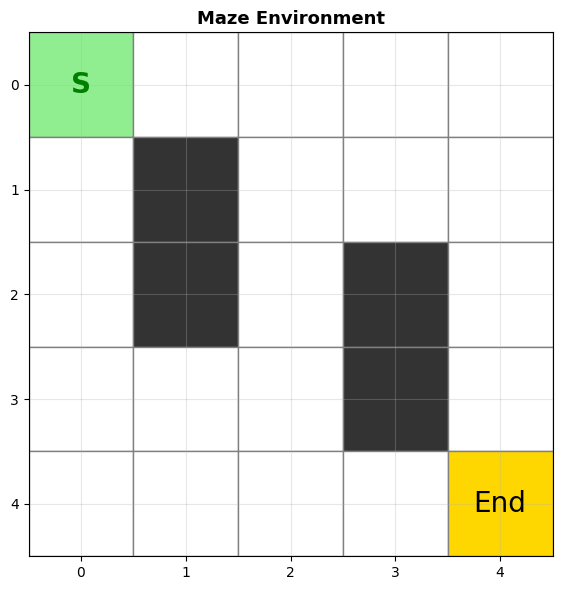

미로 규칙:
  • S(0,0)에서 출발 → End Point(4,4)에 도달하면 성공
  • 검은 칸은 벽 — 통과 불가
  • 행동: 상/하/좌/우 4가지


In [5]:
# ============================================
# 미로 환경 정의
# ============================================
GRID_SIZE = 5
START = (0, 0)
GOAL = (4, 4)
WALLS = {(1, 1), (2, 1), (2, 3), (3, 3)}  # 벽 위치

# 행동: 0=위, 1=아래, 2=왼쪽, 3=오른쪽
ACTION_NAMES = ['↑ 위', '↓ 아래', '← 왼쪽', '→ 오른쪽']
ACTION_ARROWS = ['↑', '↓', '←', '→']
ACTION_DELTAS = [(-1, 0), (1, 0), (0, -1), (0, 1)]

def step(state, action):
    """
    환경 함수: 현재 상태에서 행동을 수행한다
    
    반환값: (다음 상태, 보상, 종료 여부)
    
    보상 규칙:
    - 목표 도달: +100  (아주 좋다!)
    - 벽에 부딪힘: -1  (나쁘다)
    - 일반 이동: -0.1  (약간의 비용 → 빠른 경로를 유도)
    """
    row, col = state
    dr, dc = ACTION_DELTAS[action]
    new_row, new_col = row + dr, col + dc
    
    # 격자 밖이거나 벽이면 → 제자리, 페널티
    if (new_row < 0 or new_row >= GRID_SIZE or 
        new_col < 0 or new_col >= GRID_SIZE or 
        (new_row, new_col) in WALLS):
        return state, -1, False
    
    # 목표 도달!
    if (new_row, new_col) == GOAL:
        return (new_row, new_col), 100, True
    
    # 일반 이동
    return (new_row, new_col), -0.1, False

# 미로 시각화
def draw_grid(ax, title="", policy=None, values=None, path=None):
    ax.set_xlim(-0.5, GRID_SIZE - 0.5)
    ax.set_ylim(GRID_SIZE - 0.5, -0.5)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=13, fontweight='bold')
    
    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            color = 'white'
            if (r, c) in WALLS: color = '#333333'
            elif (r, c) == GOAL: color = '#FFD700'
            elif (r, c) == START: color = '#90EE90'
            
            ax.add_patch(patches.Rectangle((c-0.5, r-0.5), 1, 1,
                         facecolor=color, edgecolor='gray', linewidth=1))
            
            if values is not None and (r,c) not in WALLS and (r,c) != GOAL:
                v = values[r, c]
                ax.text(c, r+0.25, f'{v:.0f}', ha='center', va='center', fontsize=8, color='blue')
            
            if policy is not None and (r,c) not in WALLS and (r,c) != GOAL:
                ax.text(c, r-0.1, ACTION_ARROWS[policy[r,c]], 
                       ha='center', va='center', fontsize=16, fontweight='bold')
    
    if path:
        rows, cols = zip(*path)
        ax.plot(cols, rows, 'ro-', markersize=8, linewidth=2, alpha=0.7, zorder=5)
    
    ax.set_xticks(range(GRID_SIZE))
    ax.set_yticks(range(GRID_SIZE))
    ax.grid(True, alpha=0.3)

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
draw_grid(ax, "Maze Environment")
ax.text(0, 0, 'S', ha='center', va='center', fontsize=20, fontweight='bold', color='green')
ax.text(4, 4, 'End', ha='center', va='center', fontsize=20)
plt.tight_layout()
plt.show()

print("미로 규칙:")
print("  • S(0,0)에서 출발 → End Point(4,4)에 도달하면 성공")
print("  • 검은 칸은 벽 — 통과 불가")
print("  • 행동: 상/하/좌/우 4가지")


## 3단계: 학습 전 — 랜덤 행동

학습 전 에이전트는 **아무런 지식이 없으므로** 랜덤하게 움직입니다.

목표에 도달할 수 있을까요?


In [6]:
# ============================================
# 학습 전: 랜덤하게 움직이기
# ============================================
def run_episode_random(max_steps=50):
    """랜덤 정책으로 한 에피소드 실행"""
    state = START
    path = [state]
    total_reward = 0
    
    for _ in range(max_steps):
        action = np.random.randint(4)  # 랜덤 행동!
        next_state, reward, done = step(state, action)
        total_reward += reward
        state = next_state
        path.append(state)
        if done:
            break
    
    return path, total_reward, done

# 10번 시도
print("🎲 랜덤 행동 결과 (10회 시도)")
print("=" * 50)
successes = 0
for i in range(10):
    path, reward, reached = run_episode_random()
    status = "✅ 도달!" if reached else "❌ 실패"
    print(f"  시도 {i+1:2d}: {len(path)-1}스텝, 보상 {reward:6.1f}, {status}")
    if reached:
        successes += 1

print(f"\n성공률: {successes}/10 ({successes*10}%)")
print("→ 랜덤으로는 목표 도달이 어렵고, 도달해도 경로가 비효율적!")


🎲 랜덤 행동 결과 (10회 시도)
  시도  1: 28스텝, 보상   88.3, ✅ 도달!
  시도  2: 50스텝, 보상  -27.5, ❌ 실패
  시도  3: 29스텝, 보상   89.1, ✅ 도달!
  시도  4: 50스텝, 보상  -25.7, ❌ 실패
  시도  5: 50스텝, 보상  -20.3, ❌ 실패
  시도  6: 50스텝, 보상  -24.8, ❌ 실패
  시도  7: 50스텝, 보상  -25.7, ❌ 실패
  시도  8: 50스텝, 보상  -26.6, ❌ 실패
  시도  9: 50스텝, 보상  -22.1, ❌ 실패
  시도 10: 50스텝, 보상  -25.7, ❌ 실패

성공률: 2/10 (20%)
→ 랜덤으로는 목표 도달이 어렵고, 도달해도 경로가 비효율적!


## 4단계: Q-Table — 에이전트의 "치트 시트"

Q-Learning의 핵심 아이디어:

> **Q(상태, 행동) = "이 상태에서 이 행동을 하면 얼마나 좋은가?"**

모든 (상태, 행동) 조합에 대해 점수를 매긴 표 = **Q-Table**

```
           ↑      ↓      ←      →
(0,0)    [ 0.0,   0.0,   0.0,   0.0 ]   ← 처음엔 전부 0 (아무것도 모름)
(0,1)    [ 0.0,   0.0,   0.0,   0.0 ]
  ...
(4,3)    [ 0.0,   0.0,   0.0,  50.0 ]   ← 학습 후: "오른쪽으로 가면 좋다!"
```

에이전트는 Q값이 **가장 높은 행동**을 선택하면 됩니다!


In [7]:
# ============================================
# Q-Table 초기화
# ============================================
Q = np.zeros((GRID_SIZE, GRID_SIZE, 4))  # 5x5 격자 × 4 행동

print("Q-Table 크기:", Q.shape)
print(f"  → {GRID_SIZE}×{GRID_SIZE} 격자 × 4 행동 = {Q.size}개의 Q값")
print()

# (0,0)의 Q값 확인
print("(0,0)에서의 Q값 (학습 전):")
for a in range(4):
    print(f"  {ACTION_NAMES[a]}: Q = {Q[0, 0, a]:.1f}")
print("\n→ 전부 0이므로 어디로 갈지 모릅니다")


Q-Table 크기: (5, 5, 4)
  → 5×5 격자 × 4 행동 = 100개의 Q값

(0,0)에서의 Q값 (학습 전):
  ↑ 위: Q = 0.0
  ↓ 아래: Q = 0.0
  ← 왼쪽: Q = 0.0
  → 오른쪽: Q = 0.0

→ 전부 0이므로 어디로 갈지 모릅니다


## 5단계: Q-Learning 업데이트 공식

매 행동 후 Q값을 업데이트합니다:

$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right]$$

쉽게 풀어쓰면:
```
새 Q값 = 기존 Q값 + 학습률 × (실제 받은 보상 + 미래 기대값 - 기존 Q값)
```

| 기호 | 이름 | 의미 | 값 |
|------|------|------|-----|
| α (alpha) | 학습률 | 새 경험을 얼마나 반영할지 | 0.1 |
| γ (gamma) | 할인율 | 미래 보상을 얼마나 중요시할지 | 0.95 |
| ε (epsilon) | 탐험률 | 랜덤 행동 확률 (새로운 시도) | 0.3→0.05 |

> **탐험(Exploration) vs 활용(Exploitation)**: 가끔 랜덤으로 행동해야 새로운 경로를 발견할 수 있다!


In [8]:
# ============================================
# Q-Learning 한 스텝을 직접 해보기
# ============================================
alpha = 0.1    # 학습률
gamma = 0.95   # 할인율

# 시나리오: (0,0)에서 오른쪽(→)으로 이동
state = (0, 0)
action = 3  # 오른쪽

# 환경에서 결과 받기
next_state, reward, done = step(state, action)
print(f"현재 상태: {state}")
print(f"행동: {ACTION_NAMES[action]}")
print(f"→ 다음 상태: {next_state}, 보상: {reward}")
print()

# Q값 업데이트 계산 (한 줄씩!)
old_q = Q[state[0], state[1], action]
print(f"기존 Q({state}, {ACTION_ARROWS[action]}): {old_q:.3f}")

future_best = np.max(Q[next_state[0], next_state[1]])
print(f"미래 최대 Q값 (Q({next_state}, best)): {future_best:.3f}")

target = reward + gamma * future_best
print(f"목표값 = 보상({reward}) + γ({gamma}) × 미래 최대({future_best:.3f}) = {target:.3f}")

new_q = old_q + alpha * (target - old_q)
print(f"새 Q값 = {old_q:.3f} + α({alpha}) × ({target:.3f} - {old_q:.3f}) = {new_q:.3f}")

Q[state[0], state[1], action] = new_q
print(f"\n✅ Q({state}, →) 업데이트: {old_q:.3f} → {new_q:.3f}")
print("\n💡 보상이 -0.1(약간 나쁨)이었으므로 Q값이 살짝 음수가 되었습니다")
print("   하지만 나중에 이 방향이 목표로 가는 길이라면 점점 올라갈 것입니다!")

# Q-Table 리셋
Q = np.zeros((GRID_SIZE, GRID_SIZE, 4))


현재 상태: (0, 0)
행동: → 오른쪽
→ 다음 상태: (0, 1), 보상: -0.1

기존 Q((0, 0), →): 0.000
미래 최대 Q값 (Q((0, 1), best)): 0.000
목표값 = 보상(-0.1) + γ(0.95) × 미래 최대(0.000) = -0.100
새 Q값 = 0.000 + α(0.1) × (-0.100 - 0.000) = -0.010

✅ Q((0, 0), →) 업데이트: 0.000 → -0.010

💡 보상이 -0.1(약간 나쁨)이었으므로 Q값이 살짝 음수가 되었습니다
   하지만 나중에 이 방향이 목표로 가는 길이라면 점점 올라갈 것입니다!


## 6단계: 전체 Q-Learning 실행 — 학습 관찰! 🚀

이제 에이전트가 수백 번의 에피소드를 통해 학습합니다.

각 에피소드:
1. 시작점에서 출발
2. ε-greedy로 행동 선택 (가끔 랜덤 = 탐험)
3. 행동 → 보상 → Q-Table 업데이트
4. 목표 도달 or 최대 스텝 → 끝 → 다시 1번


In [9]:
# ============================================
# Q-Learning 전체 실행
# ============================================
Q = np.zeros((GRID_SIZE, GRID_SIZE, 4))

alpha = 0.1
gamma = 0.95
num_episodes = 500

episode_rewards = []
episode_steps = []
episode_success = []

for ep in range(num_episodes):
    state = START
    total_reward = 0
    
    # epsilon 감소: 초기엔 많이 탐험, 후반엔 학습된 정책 활용
    epsilon = max(0.05, 0.5 - ep * 0.002)
    
    for step_count in range(100):
        # ε-greedy 행동 선택
        if np.random.rand() < epsilon:
            action = np.random.randint(4)     # 탐험 (랜덤)
        else:
            action = np.argmax(Q[state[0], state[1]])  # 활용 (최고 Q)
        
        # 환경에서 결과 받기
        next_state, reward, done = step(state, action)
        
        # Q-Table 업데이트!
        old_q = Q[state[0], state[1], action]
        next_max_q = np.max(Q[next_state[0], next_state[1]])
        Q[state[0], state[1], action] = old_q + alpha * (
            reward + gamma * next_max_q - old_q
        )
        
        total_reward += reward
        state = next_state
        
        if done:
            break
    
    episode_rewards.append(total_reward)
    episode_steps.append(step_count + 1)
    episode_success.append(done)
    
    if (ep + 1) % 100 == 0:
        recent_rewards = episode_rewards[-50:]
        recent_success = sum(episode_success[-50:])
        print(f"  Episode {ep+1:4d} | "
              f"Avg Reward: {np.mean(recent_rewards):6.1f} | "
              f"Success: {recent_success}/50 | "
              f"ε: {epsilon:.3f}")

print(f"\n✅ 학습 완료! ({num_episodes} 에피소드)")


  Episode  100 | Avg Reward:   97.5 | Success: 50/50 | ε: 0.302
  Episode  200 | Avg Reward:   98.5 | Success: 50/50 | ε: 0.102
  Episode  300 | Avg Reward:   99.0 | Success: 50/50 | ε: 0.050
  Episode  400 | Avg Reward:   99.2 | Success: 50/50 | ε: 0.050
  Episode  500 | Avg Reward:   99.2 | Success: 50/50 | ε: 0.050

✅ 학습 완료! (500 에피소드)


## 7단계: 학습 결과 확인

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_41684\2117342263.py:32: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


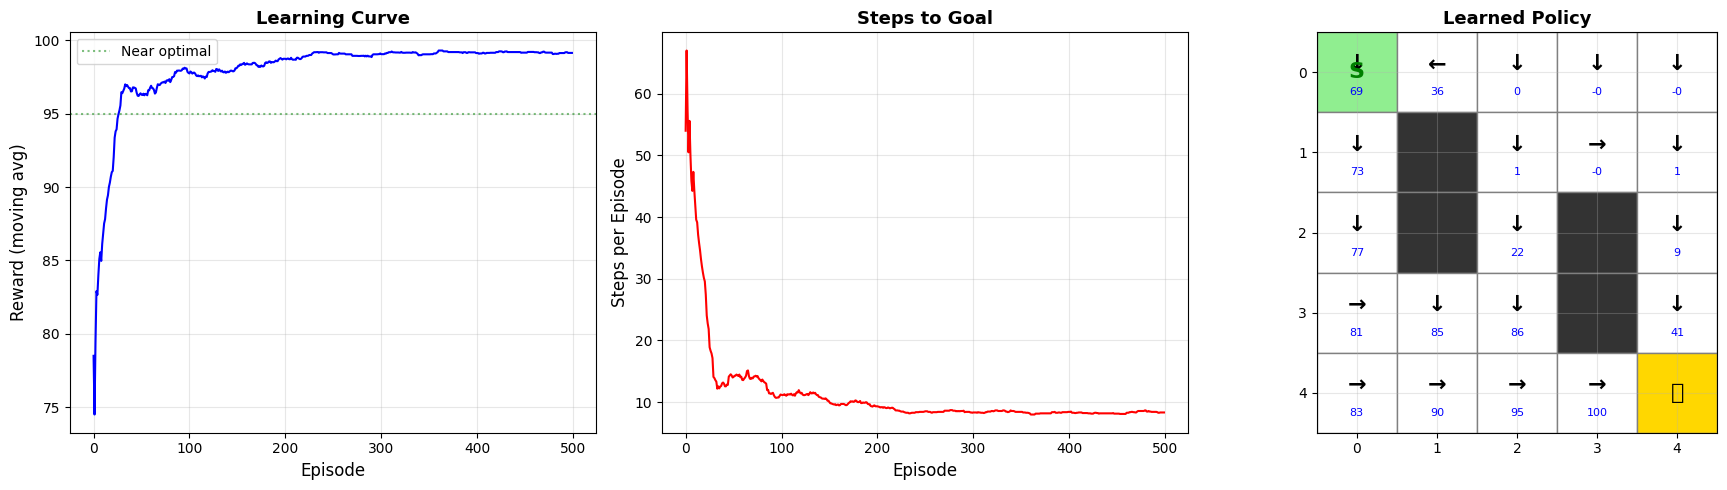

📊 관찰 포인트:
  1. 보상이 점점 올라감 → 학습이 진행됨!
  2. 스텝 수가 점점 줄어듦 → 경로가 효율적으로 됨!
  3. 화살표가 목표를 향해 정렬됨 → 최적 정책 학습!
  4. Q값(숫자)이 목표 근처에서 높음 → '여기가 좋은 곳'이라고 학습


In [10]:
# ============================================
# 학습 곡선 + 학습된 정책 시각화
# ============================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) 보상 변화
window = 20
smoothed = [np.mean(episode_rewards[max(0,i-window):i+1]) for i in range(len(episode_rewards))]
axes[0].plot(smoothed, 'b-', linewidth=1.5)
axes[0].set_xlabel('Episode', fontsize=12)
axes[0].set_ylabel('Reward (moving avg)', fontsize=12)
axes[0].set_title('Learning Curve', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=95, color='green', linestyle=':', alpha=0.5, label='Near optimal')
axes[0].legend()

# 2) 스텝 수 변화
smoothed_steps = [np.mean(episode_steps[max(0,i-window):i+1]) for i in range(len(episode_steps))]
axes[1].plot(smoothed_steps, 'r-', linewidth=1.5)
axes[1].set_xlabel('Episode', fontsize=12)
axes[1].set_ylabel('Steps per Episode', fontsize=12)
axes[1].set_title('Steps to Goal', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# 3) 학습된 정책
policy = np.argmax(Q, axis=2)
max_q_values = np.max(Q, axis=2)
draw_grid(axes[2], "Learned Policy", policy=policy, values=max_q_values)
axes[2].text(0, 0, 'S', ha='center', va='center', fontsize=16, fontweight='bold', color='green', zorder=10)
axes[2].text(4, 4, '⭐', ha='center', va='center', fontsize=16, zorder=10)

plt.tight_layout()
plt.show()

print("📊 관찰 포인트:")
print("  1. 보상이 점점 올라감 → 학습이 진행됨!")
print("  2. 스텝 수가 점점 줄어듦 → 경로가 효율적으로 됨!")
print("  3. 화살표가 목표를 향해 정렬됨 → 최적 정책 학습!")
print("  4. Q값(숫자)이 목표 근처에서 높음 → '여기가 좋은 곳'이라고 학습")


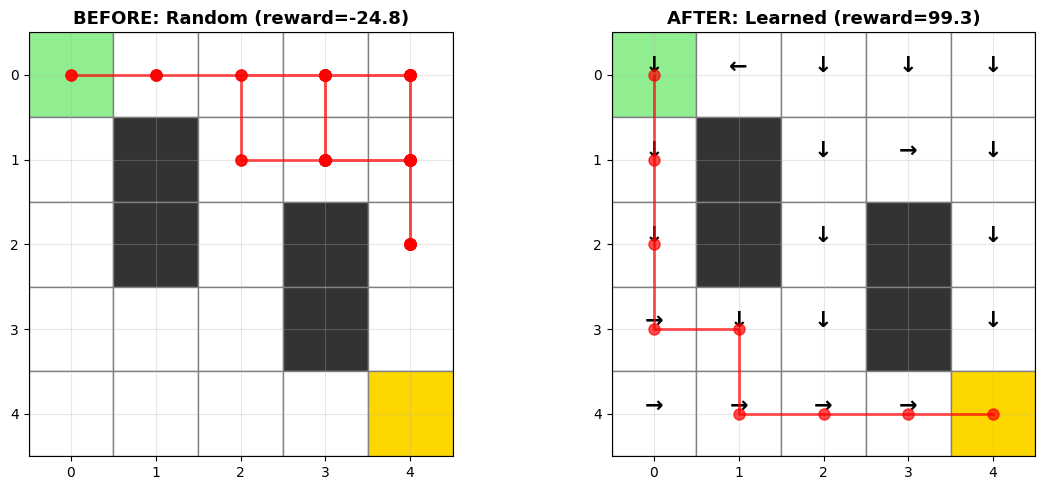

학습 전: 50스텝, 보상 -24.8
학습 후: 8스텝, 보상 99.3
→ 학습 후 에이전트는 벽을 피해 최단 경로로 목표에 도달합니다!


In [11]:
# ============================================
# 학습된 정책으로 실제 경로 확인
# ============================================
def run_learned_policy(Q):
    """학습된 Q-Table로 최적 경로 실행"""
    state = START
    path = [state]
    total_reward = 0
    
    for _ in range(50):
        action = np.argmax(Q[state[0], state[1]])  # 항상 최고 Q 선택
        next_state, reward, done = step(state, action)
        total_reward += reward
        state = next_state
        path.append(state)
        if done:
            break
    
    return path, total_reward, done

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 학습 전 (랜덤)
np.random.seed(0)
random_path, r_reward, _ = run_episode_random(50)
draw_grid(axes[0], f"BEFORE: Random (reward={r_reward:.1f})", path=random_path)

# 학습 후
learned_path, l_reward, l_done = run_learned_policy(Q)
draw_grid(axes[1], f"AFTER: Learned (reward={l_reward:.1f})", path=learned_path, policy=np.argmax(Q, axis=2))

plt.tight_layout()
plt.show()

print(f"학습 전: {len(random_path)-1}스텝, 보상 {r_reward:.1f}")
print(f"학습 후: {len(learned_path)-1}스텝, 보상 {l_reward:.1f}")
print(f"→ 학습 후 에이전트는 벽을 피해 최단 경로로 목표에 도달합니다!")


## 🔬 직접 실험해보기!

아래 파라미터를 바꿔보고 결과가 어떻게 달라지는지 관찰하세요.

| 실험 | 변경할 것 | 예상 | 확인 |
|------|----------|------|------|
| A | `alpha=0.01` (학습률 줄임) | 학습이 느려질까? | |
| B | `alpha=0.9` (학습률 높임) | 불안정해질까? | |
| C | `gamma=0.5` (할인율 줄임) | 먼 보상을 무시할까? | |
| D | `epsilon 고정 0.5` | 계속 랜덤이면? | |


In [ ]:
# ============================================
# 🔬 실험: 파라미터를 바꿔보세요!
# ============================================

# ▼▼▼ 이 값들을 바꿔보세요 ▼▼▼
EXP_ALPHA = 0.1       # 학습률 (시도: 0.01, 0.1, 0.5, 0.9)
EXP_GAMMA = 0.95      # 할인율 (시도: 0.1, 0.5, 0.95, 0.99)
EXP_EPSILON_DECAY = True  # False로 바꾸면 epsilon 고정
# ▲▲▲ 이 값들을 바꿔보세요 ▲▲▲

Q_exp = np.zeros((GRID_SIZE, GRID_SIZE, 4))
exp_rewards = []

for ep in range(500):
    state = START; total_r = 0
    epsilon = max(0.05, 0.5 - ep*0.002) if EXP_EPSILON_DECAY else 0.3
    
    for _ in range(100):
        if np.random.rand() < epsilon:
            action = np.random.randint(4)
        else:
            action = np.argmax(Q_exp[state[0], state[1]])
        
        ns, r, done = step(state, action)
        old = Q_exp[state[0], state[1], action]
        Q_exp[state[0], state[1], action] = old + EXP_ALPHA * (
            r + EXP_GAMMA * np.max(Q_exp[ns[0], ns[1]]) - old)
        total_r += r; state = ns
        if done: break
    exp_rewards.append(total_r)

plt.figure(figsize=(10, 4))
w = 20
smoothed = [np.mean(exp_rewards[max(0,i-w):i+1]) for i in range(len(exp_rewards))]
plt.plot(smoothed, linewidth=2)
plt.xlabel('Episode'); plt.ylabel('Reward')
plt.title(f'alpha={EXP_ALPHA}, gamma={EXP_GAMMA}, decay={EXP_EPSILON_DECAY}', fontsize=13)
plt.grid(True, alpha=0.3)
plt.show()

print(f"최종 50 에피소드 평균 보상: {np.mean(exp_rewards[-50:]):.1f}")


## 📝 핵심 정리

### Q-Learning의 학습 과정
```
[시작] → 랜덤 행동 → 보상 받음 → Q-Table 업데이트 → 반복
                ↓
        점점 Q값이 정확해짐 → Q값 높은 행동 선택 → 최적 경로!
```

### 핵심 개념
- **Q값** = "이 상태에서 이 행동이 얼마나 좋은지"에 대한 에이전트의 **경험적 지식**
- **탐험(ε)** = 가끔 랜덤 행동 → 새로운 경로 발견 → 다양한 경험
- **할인율(γ)** = 미래 보상의 중요도 → 높으면 장기적, 낮으면 근시안적
- **보상 설계** = AI의 행동을 결정! (Lab 2에서 더 자세히)

### 다음 시간 예고
> Lab 2에서는 **보상 함수를 바꾸면 같은 에이전트가 완전히 다른 행동을 학습**하는 것을 확인합니다!
